In [ ]:
import warnings
warnings.filterwarnings("ignore")    

In [1]:
import spatialdata as sd
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad
from matplotlib.colors import ListedColormap

import pickle
   

/software/cellgen/team298/ls34/NEMO2/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team298/ls34/NEMO2/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
sc.settings.figdir = "supp"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(25,25))


In [3]:
#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.v8_nohealthy')
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
adata=sc.read_h5ad(PATH)
adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
adata=adata[adata.obs["tech"]!="xenium"].copy()

#adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')

import gc
gc.collect()


#adata=sc.read_h5ad(PATH2)
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST

 

 

In [4]:
adata_5k.obs["Annotation"]=adata_5k.obs["lvl5_annotation"]
adata_5k.obs["Annotation"].value_counts()

Annotation
KC3                 189820
KC1                 126090
F2: Universal       100872
Pericyte1            85232
VE3_Ven              69056
                     ...  
Neutrophil              17
KC_HF: HS               14
ILC_Prolif              12
ILC1_NCR2+P2RX7+         8
Mac_CX3CR1+              8
Name: count, Length: 100, dtype: int64

0 True
BK50_Never Lesional - Cell count:  1


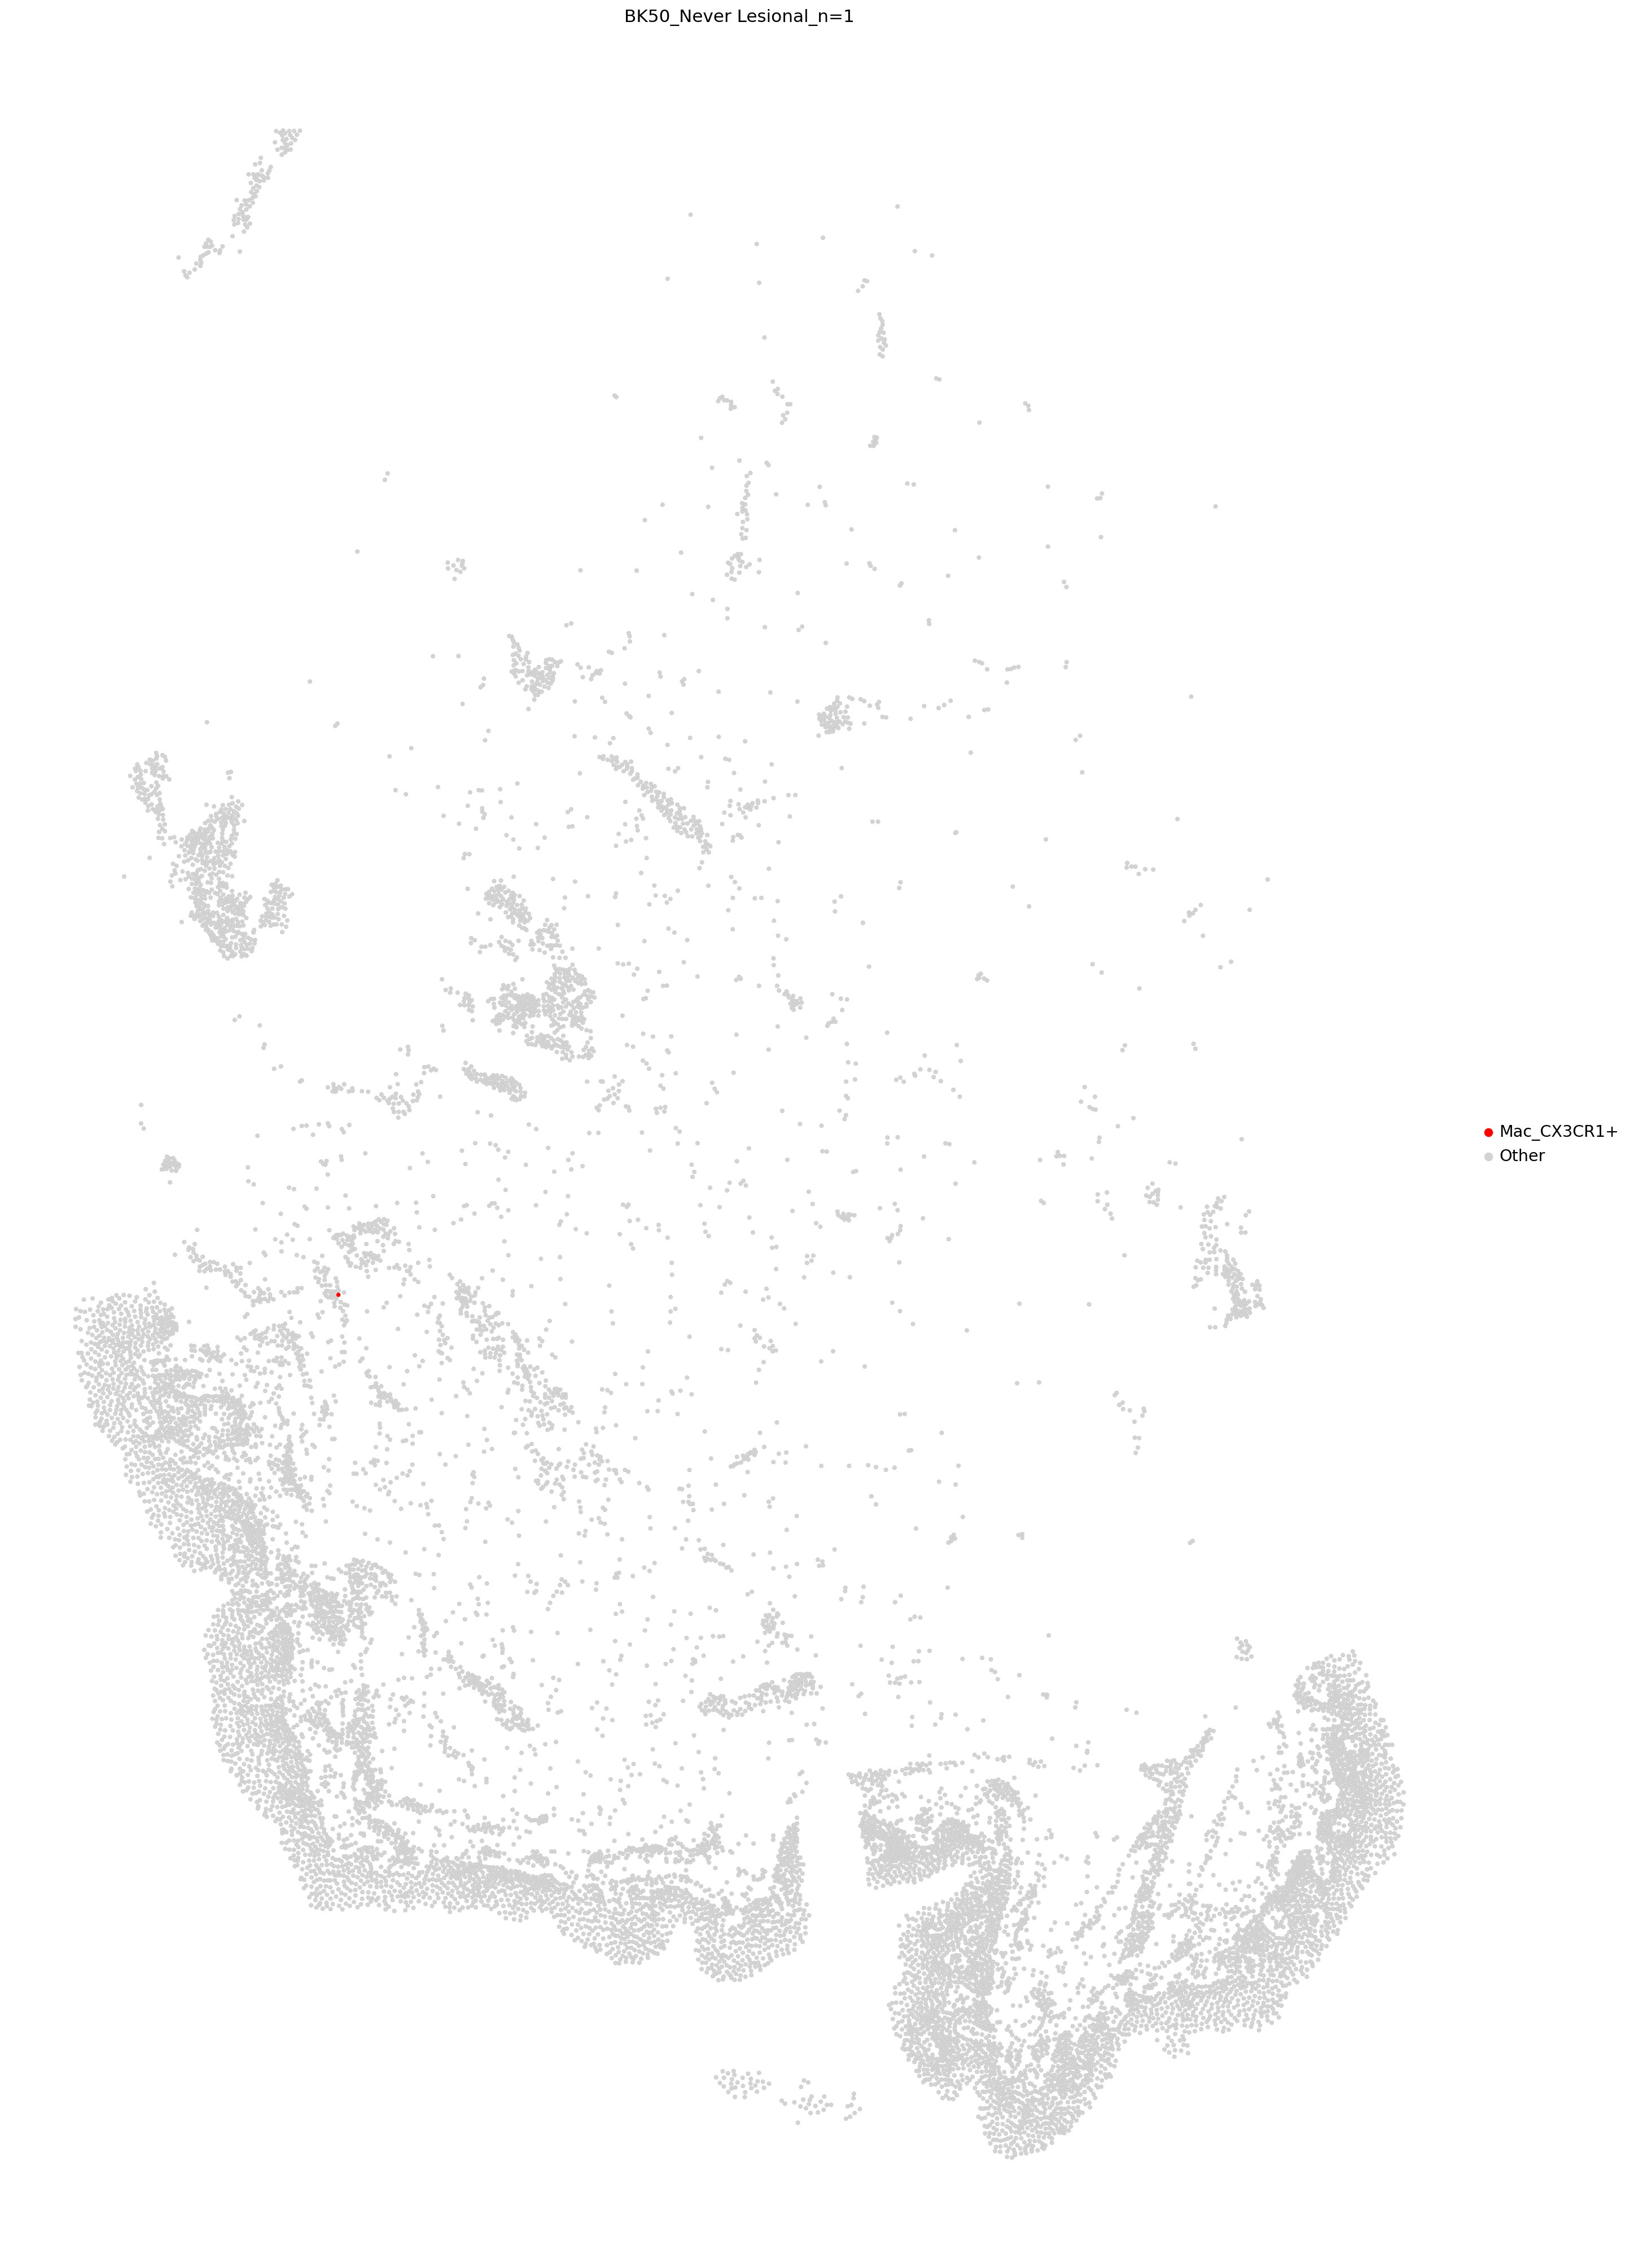

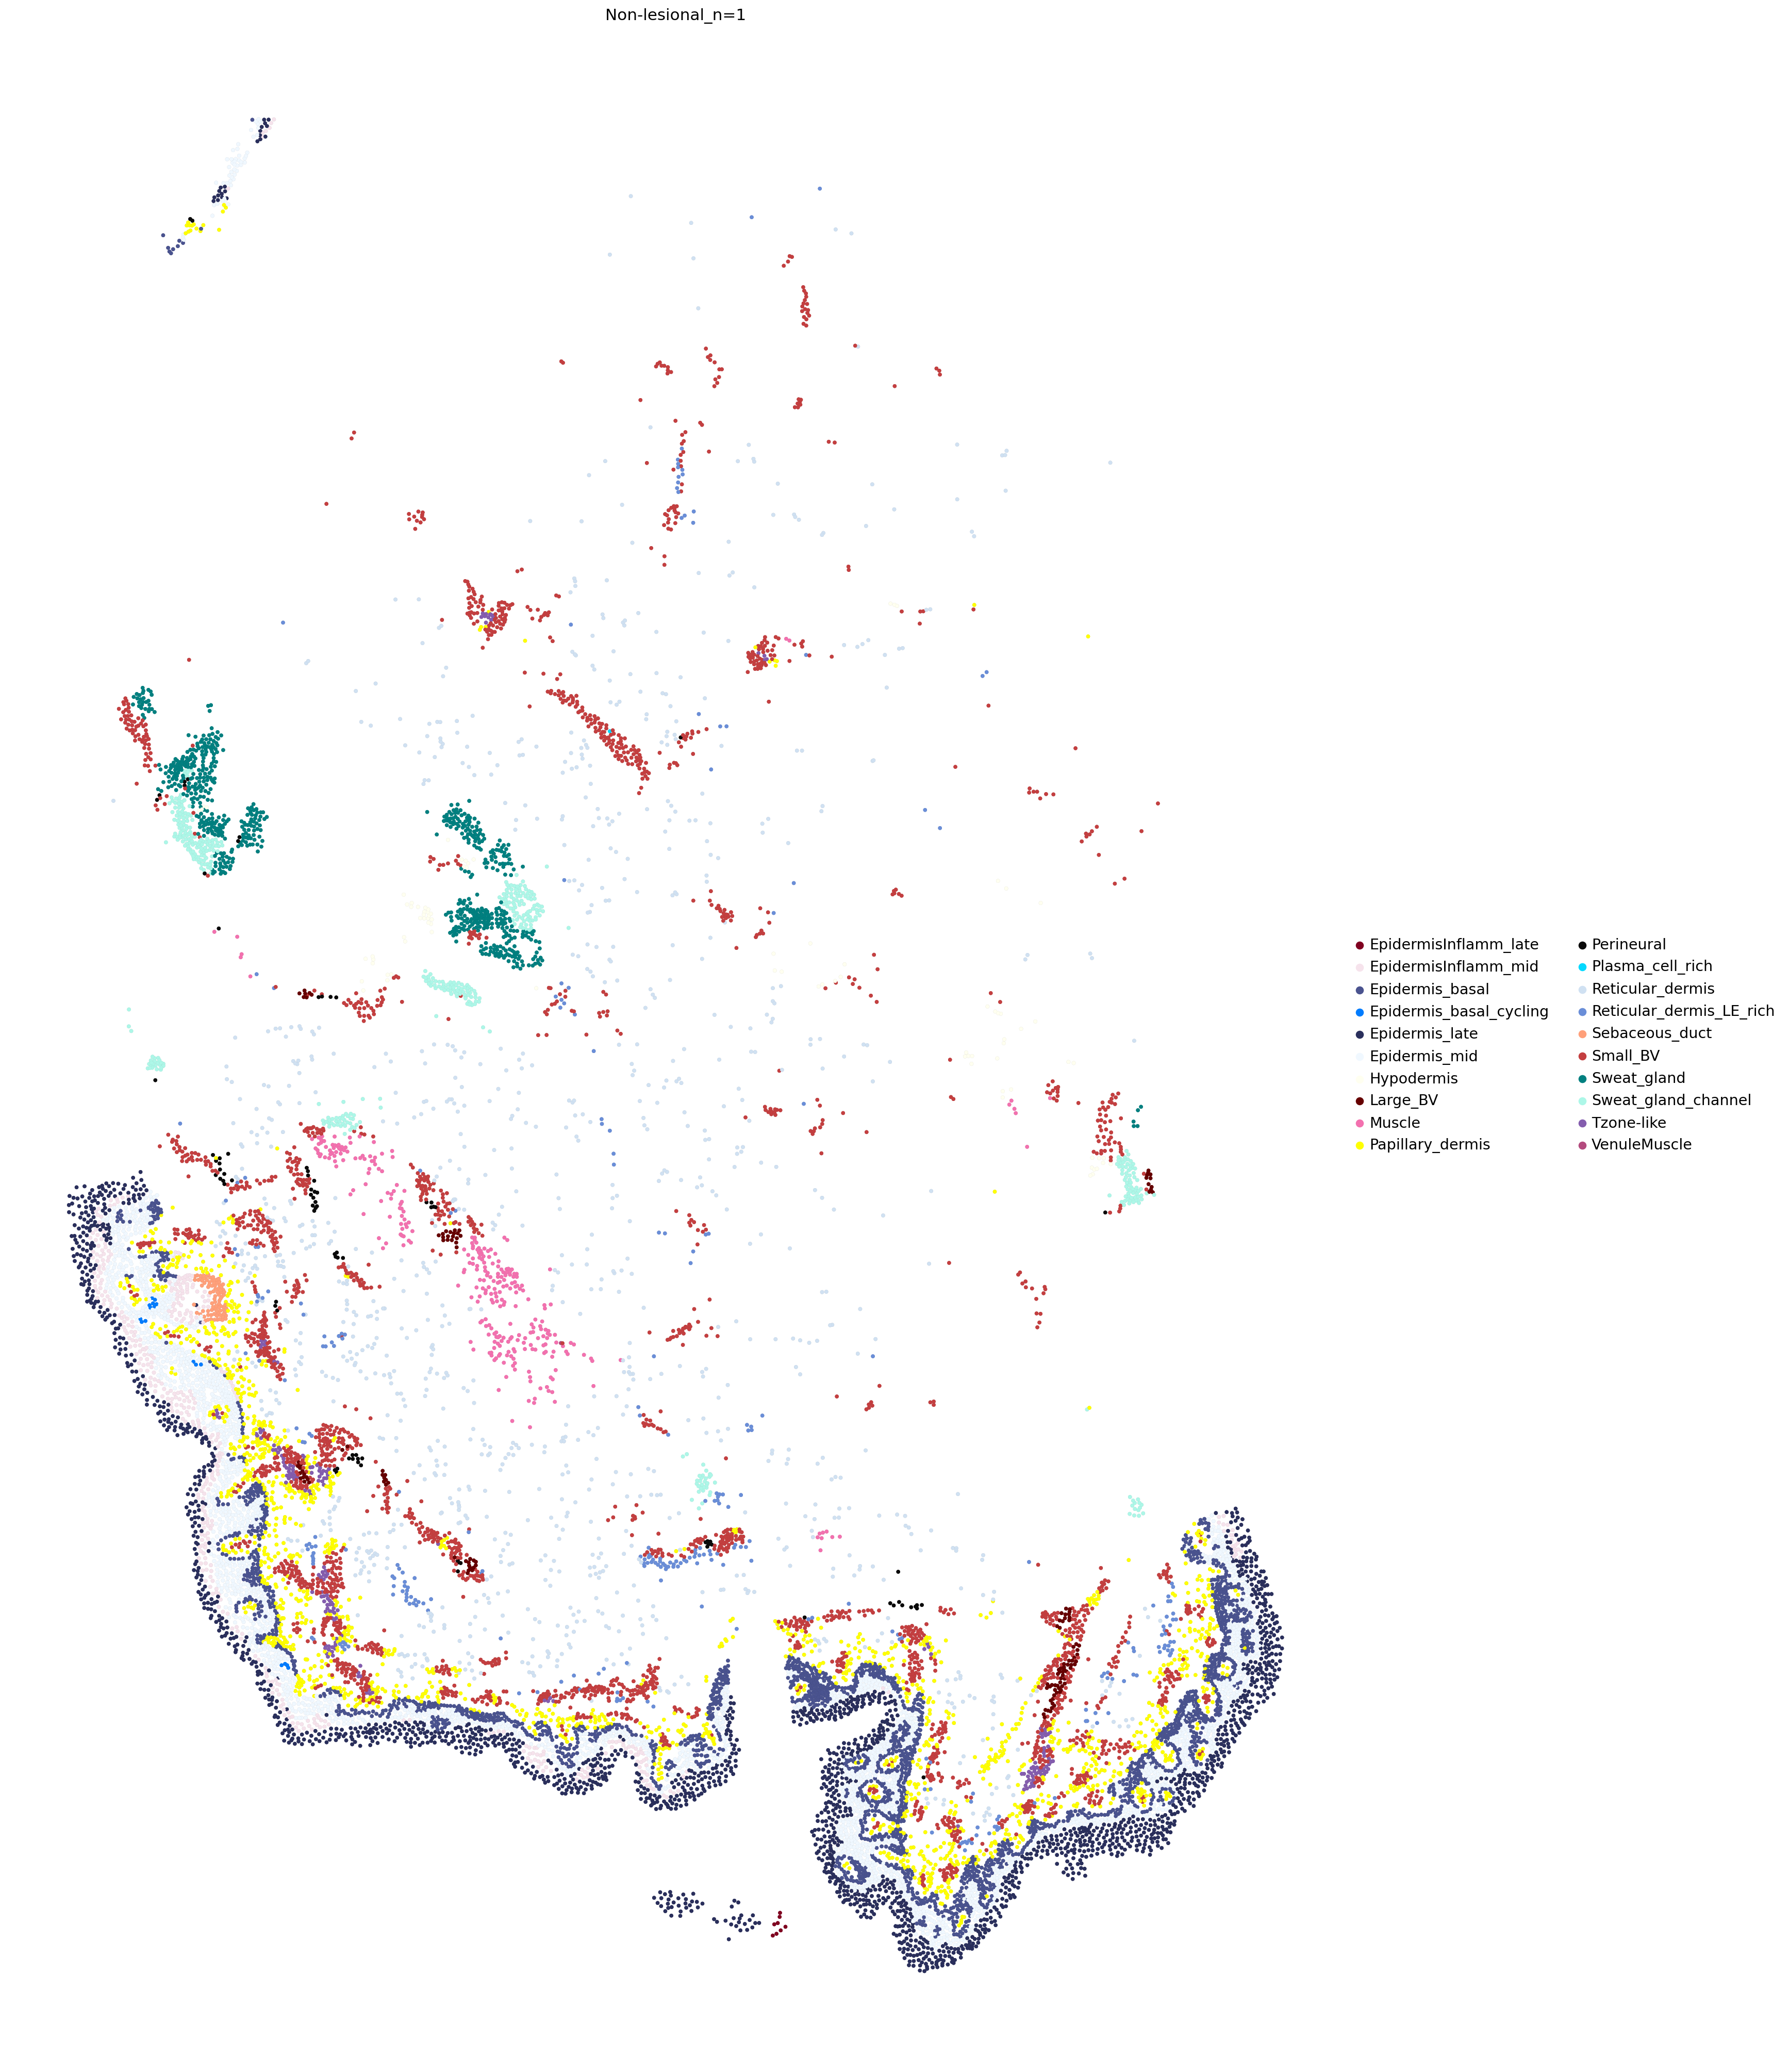

In [8]:

#['Mac', 'Mac_CCL14hi', 'Mac LPLhi', 'Mac_prolif/PreDC', 'Mac LPLhi (P2RY12-)']

CELL_TYPE = 'Mac_CX3CR1+'
MIN_CELL_COUNT=0


i=0
#adata_5k=adata_5k[adata_5k.obs["Site_status_binary"]=="Lesional"]
for tissue_section_id in ["BK50_Never Lesional"]:
    adata_i =  adata_5k[adata_5k.obs["info_id6"]==tissue_section_id]
    niche_names_found = adata_i.obs["Annotation"].unique()
    STATUS =  adata_i.obs["Site_status"].unique()[0]
    print(i, CELL_TYPE in niche_names_found)
#     if tissue_section_id=="output-XETG00335__0044073__BK49-SKI-24-FO-1-s2_BK50-SKI-27-FO-1-s2__20250210__163417":
#         print(tissue_section_id)
#         display(adata_i.obs["Annotation"].value_counts())
    if CELL_TYPE in niche_names_found:
        CELL_COUNT_IN_SECTION=adata_i[adata_i.obs["Annotation"]==CELL_TYPE].shape[0]
        print(tissue_section_id, "- Cell count: ", CELL_COUNT_IN_SECTION)

        if CELL_COUNT_IN_SECTION > MIN_CELL_COUNT:
    #         if i ==0:

    #             sq.pl.spatial_scatter(
    #                 adata_i,
    #                 library_id="spatial",
    #                 shape=None,
    #                 color="Annotation",
    #                 size=1,
    #                 vmax=1,
    #                 title=tissue_section_id,
    #                 #ax=ax,
    #                 #legend_loc="on data"  # Disable the legend for each subplot
    #             )       
            i=i+1

            #print(tissue_section_id)
    #         sq.pl.spatial_scatter(
    #             adata_i,
    #             library_id="spatial",
    #             shape=None,
    #             color="Annotation",
    #             size=5,
    #             vmax=1,
    #             title=tissue_section_id,
    #             #ax=ax,
    #             legend_loc="on data"  # Disable the legend for each subplot
    #         )
            adata_i.obs["test"] = [x if x == CELL_TYPE else "Other" for x in adata_i.obs["Annotation"]]
            NUM = ord(CELL_TYPE[0])
            if NUM <79:
                custom_palette =ListedColormap([  "red",  "lightgrey"])
            else:
                custom_palette = ListedColormap([  "lightgrey", "red"])
            sq.pl.spatial_scatter(
                    adata_i,
                    library_id="spatial",
                    shape=None,
                    color="test",
                    size=45,
                    vmax=1,   linewidth=0.01,
                    edgecolor='black',
                    title=tissue_section_id + "_n=" + str(CELL_COUNT_IN_SECTION),
                    palette=custom_palette,

                    #ax=ax,
                    #legend_loc="on data"  # Disable the legend for each subplot
                )
            
            sq.pl.spatial_scatter(
                    adata_i,
                    library_id="spatial",
                    shape=None,
                    color="niche19",
                    size=45,
                    vmax=1,
                    linewidth=0.01,
                    edgecolor='black',
                    title=STATUS + "_n=" + str(CELL_COUNT_IN_SECTION),
                    #palette=custom_palette,

                    #ax=ax,
                    #legend_loc="on data"  # Disable the legend for each subplot
                )
#             if i >5:
#                 print("6 samples found already ... Terminate")
#                 break
        else:
             print(STATUS, " - does not contain ", CELL_TYPE, ". Count is " , CELL_COUNT_IN_SECTION,)# " - i=", i)